# MobileNetV3 Training Pipeline

In [ ]:
# =========================================================
# CELL 1: Imports and setup
# =========================================================
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf
from google.colab import drive

print("TensorFlow version:", tf.__version__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

drive.mount("/content/drive")

# Change this only if your folder is not directly under MyDrive
DATASET_ROOT = "/content/drive/MyDrive/dataset_sg"

CLASS_NAMES = [
    "bat",
    "common_flameback",
    "human",
    "macaque",
    "monitor_lizard",
    "otter",
    "palm_civet",
    "snake",
    "squirrel",
    "wild_boar",
]

IMG_SIZE = 224         # recommended starting point for Zero 2 W
BATCH_SIZE = 32
VAL_FRAC = 0.15
TEST_FRAC = 0.15
AUTOTUNE = tf.data.AUTOTUNE

ALLOWED_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("Dataset root:", DATASET_ROOT)
print("Classes:", CLASS_NAMES)

TensorFlow version: 2.19.0
Mounted at /content/drive
Dataset root: /content/drive/MyDrive/dataset_sg
Classes: ['bat', 'common_flameback', 'human', 'macaque', 'monitor_lizard', 'otter', 'palm_civet', 'snake', 'squirrel', 'wild_boar']


In [ ]:
# =========================================================
# CELL 2: Scan files, skip /rejected/, drop corrupt images,
# and extract observation IDs for grouped splitting
# =========================================================
import re

dataset_root = Path(DATASET_ROOT)
class_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
idx_to_class = {i: name for name, i in class_to_idx.items()}

records = []
bad_files = []

obs_pattern = re.compile(r"(obs_\d+)")

for class_name in CLASS_NAMES:
    class_dir = dataset_root / class_name
    if not class_dir.exists():
        raise FileNotFoundError(f"Missing class folder: {class_dir}")

    for fp in class_dir.rglob("*"):
        if not fp.is_file():
            continue
        if fp.suffix.lower() not in ALLOWED_EXTS:
            continue
        if "rejected" in [p.lower() for p in fp.parts]:
            continue

        try:
            with Image.open(fp) as im:
                im.verify()

            m = obs_pattern.search(fp.name)
            if m:
                obs_id = m.group(1)
            else:
                # Fallback: treat file as its own observation if pattern not found
                obs_id = fp.stem

            records.append((str(fp), class_to_idx[class_name], obs_id))
        except Exception:
            bad_files.append(str(fp))

if not records:
    raise RuntimeError("No usable images found. Check DATASET_ROOT and folder names.")

paths   = np.array([r[0] for r in records])
labels  = np.array([r[1] for r in records], dtype=np.int32)
obs_ids = np.array([r[2] for r in records])

print("Usable images:", len(paths))
print("Corrupt/invalid images skipped:", len(bad_files))

counts = Counter(labels.tolist())
for idx in range(len(CLASS_NAMES)):
    print(f"{idx_to_class[idx]:18s}: {counts.get(idx, 0)}")

# Observation-level summary
obs_to_label = {}
for _, label, obs_id in records:
    if obs_id in obs_to_label and obs_to_label[obs_id] != label:
        raise RuntimeError(f"Observation {obs_id} appears in multiple classes.")
    obs_to_label[obs_id] = label

unique_obs = np.array(list(obs_to_label.keys()))
unique_obs_labels = np.array([obs_to_label[o] for o in unique_obs], dtype=np.int32)

print("\nUnique observations:", len(unique_obs))
obs_counts = Counter(unique_obs_labels.tolist())
for idx in range(len(CLASS_NAMES)):
    print(f"{idx_to_class[idx]:18s} obs: {obs_counts.get(idx, 0)}")

min_obs_count = min(obs_counts.values())
if min_obs_count < 3:
    raise RuntimeError(
        "At least one class has fewer than 3 unique observations. "
        "Observation-level train/val/test split will not be reliable."
    )

Usable images: 2593
Corrupt/invalid images skipped: 0
bat               : 294
common_flameback  : 251
human             : 122
macaque           : 329
monitor_lizard    : 315
otter             : 273
palm_civet        : 200
snake             : 280
squirrel          : 291
wild_boar         : 238

Unique observations: 2593
bat                obs: 294
common_flameback   obs: 251
human              obs: 122
macaque            obs: 329
monitor_lizard     obs: 315
otter              obs: 273
palm_civet         obs: 200
snake              obs: 280
squirrel           obs: 291
wild_boar          obs: 238


In [ ]:
# =========================================================
# CELL 3: Stratified train/val/test split by observation ID
# =========================================================
# Split unique observations, not individual images
train_obs, temp_obs, train_obs_labels, temp_obs_labels = train_test_split(
    unique_obs,
    unique_obs_labels,
    test_size=(VAL_FRAC + TEST_FRAC),
    stratify=unique_obs_labels,
    random_state=SEED,
)

relative_test_frac = TEST_FRAC / (VAL_FRAC + TEST_FRAC)

val_obs, test_obs, val_obs_labels, test_obs_labels = train_test_split(
    temp_obs,
    temp_obs_labels,
    test_size=relative_test_frac,
    stratify=temp_obs_labels,
    random_state=SEED,
)

train_obs_set = set(train_obs.tolist())
val_obs_set   = set(val_obs.tolist())
test_obs_set  = set(test_obs.tolist())

# Sanity check: no observation leakage
assert train_obs_set.isdisjoint(val_obs_set)
assert train_obs_set.isdisjoint(test_obs_set)
assert val_obs_set.isdisjoint(test_obs_set)

# Map observation split back to image-level arrays
train_mask = np.array([o in train_obs_set for o in obs_ids])
val_mask   = np.array([o in val_obs_set   for o in obs_ids])
test_mask  = np.array([o in test_obs_set  for o in obs_ids])

train_paths, train_labels = paths[train_mask], labels[train_mask]
val_paths,   val_labels   = paths[val_mask],   labels[val_mask]
test_paths,  test_labels  = paths[test_mask],  labels[test_mask]

print("Train images:", len(train_paths))
print("Val images  :", len(val_paths))
print("Test images :", len(test_paths))

print("Train obs   :", len(train_obs))
print("Val obs     :", len(val_obs))
print("Test obs    :", len(test_obs))

print("\nPer-class image counts by split:")
for idx in range(len(CLASS_NAMES)):
    train_n = int(np.sum(train_labels == idx))
    val_n   = int(np.sum(val_labels == idx))
    test_n  = int(np.sum(test_labels == idx))
    print(f"{idx_to_class[idx]:18s} train={train_n:4d}  val={val_n:4d}  test={test_n:4d}")

Train images: 1815
Val images  : 389
Test images : 389
Train obs   : 1815
Val obs     : 389
Test obs    : 389

Per-class image counts by split:
bat                train= 206  val=  44  test=  44
common_flameback   train= 176  val=  38  test=  37
human              train=  85  val=  19  test=  18
macaque            train= 230  val=  49  test=  50
monitor_lizard     train= 220  val=  47  test=  48
otter              train= 191  val=  41  test=  41
palm_civet         train= 140  val=  30  test=  30
snake              train= 196  val=  42  test=  42
squirrel           train= 204  val=  43  test=  44
wild_boar          train= 167  val=  36  test=  35


In [ ]:
# =========================================================
# CELL 4: tf.data pipeline
# =========================================================
def decode_and_resize(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], antialias=True)
    img = tf.cast(img, tf.float32)   # keep [0,255] because MobileNetV3 can include preprocessing
    return img, label

augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomBrightness(0.15, value_range=(0, 255)),
    tf.keras.layers.RandomContrast(0.15),
], name="augmenter")

def add_train_aug(img, label):
    img = augmenter(img, training=True)
    # mild noise to mimic webcam/screen capture imperfections
    img = img + tf.random.normal(tf.shape(img), mean=0.0, stddev=2.0)
    img = tf.clip_by_value(img, 0.0, 255.0)
    return img, label

def make_ds(paths, labels, training=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(add_train_aug, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_paths, train_labels, training=True, augment=True)
train_ds_noaug = make_ds(train_paths, train_labels, training=False, augment=False)
val_ds = make_ds(val_paths, val_labels, training=False, augment=False)
test_ds = make_ds(test_paths, test_labels, training=False, augment=False)

In [ ]:
# =========================================================
# CELL 5: Class weights (helpful if classes are imbalanced)
# =========================================================
train_counts = Counter(train_labels.tolist())
num_classes = len(CLASS_NAMES)
total_train = len(train_labels)

class_weight = {
    i: total_train / (num_classes * train_counts[i])
    for i in range(num_classes)
}

print("Class weights:")
for i in range(num_classes):
    print(f"{idx_to_class[i]:18s}: {class_weight[i]:.3f}")

Class weights:
bat               : 0.881
common_flameback  : 1.031
human             : 2.135
macaque           : 0.789
monitor_lizard    : 0.825
otter             : 0.950
palm_civet        : 1.296
snake             : 0.926
squirrel          : 0.890
wild_boar         : 1.087


In [ ]:
# =========================================================
# CELL 6: Build MobileNetV3Small model
# =========================================================
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    alpha=1.0,
    minimalistic=False,
    include_top=False,
    weights="imagenet",
    pooling=None,
    dropout_rate=0.2,
    include_preprocessing=True,   # accepts [0,255] float images
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="predictions")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="acc"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc"),
    ],
)

model.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         5,770 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 944,890 (3.60 MB)

 Trainable params: 5,770 (22.54 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [ ]:
# =========================================================
# CELL 7: Train classifier head
# =========================================================
callbacks_head = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_acc",
        patience=4,
        mode="max",
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1,
    ),
]

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight,
    callbacks=callbacks_head,
)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - acc: 0.3978 - loss: 1.8066 - top3_acc: 0.6567 - val_acc: 0.7172 - val_loss: 1.0427 - val_top3_acc: 0.9023 - learning_rate: 0.0010
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - acc: 0.6689 - loss: 1.0309 - top3_acc: 0.8915 - val_acc: 0.7815 - val_loss: 0.7369 - val_top3_acc: 0.9434 - learning_rate: 0.0010
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - acc: 0.7493 - loss: 0.8066 - top3_acc: 0.9163 - val_acc: 0.8098 - val_loss: 0.6189 - val_top3_acc: 0.9614 - learning_rate: 0.0010
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - acc: 0.7686 - loss: 0.7260 - top3_acc: 0.9267 - val_acc: 0.8175 - val_loss: 0.5572 - val_top3_acc: 0.9614 - learning_rate: 0.0010
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - acc: 0.7785 - loss: 0.6629 - top3_acc: 0.9366 - val_acc: 0.8201 - val_loss: 0.5166 - val_top3_acc: 0.9666 - learning_rate: 0.0010
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - acc: 0.7923 - loss: 0.6130 - top3_acc:

In [ ]:
# =========================================================
# CELL 8: Fine-tune last part of backbone
# =========================================================
base_model.trainable = True

# Freeze most of the backbone; unfreeze only the last ~30 layers
fine_tune_layers = 30
for layer in base_model.layers[:-fine_tune_layers]:
    layer.trainable = False

# Keep BatchNorm frozen for safer fine-tuning
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="acc"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc"),
    ],
)

callbacks_ft = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_acc",
        patience=4,
        mode="max",
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1,
    ),
]

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight,
    callbacks=callbacks_ft,
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - acc: 0.8479 - loss: 0.4512 - top3_acc: 0.9702 - val_acc: 0.8638 - val_loss: 0.4046 - val_top3_acc: 0.9794 - learning_rate: 1.0000e-05
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - acc: 0.8479 - loss: 0.4491 - top3_acc: 0.9636 - val_acc: 0.8638 - val_loss: 0.3952 - val_top3_acc: 0.9743 - learning_rate: 1.0000e-05
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - acc: 0.8512 - loss: 0.4273 - top3_acc: 0.9725 - val_acc: 0.8663 - val_loss: 0.3890 - val_top3_acc: 0.9743 - learning_rate: 1.0000e-05
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - acc: 0.8612 - loss: 0.4044 - top3_acc: 0.9730 - val_acc: 0.8663 - val_loss: 0.3838 - val_top3_acc: 0.9769 - learning_rate: 1.0000e-05
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - acc: 0.8507 - loss: 0.4258 - top3_acc: 0.9713 - val_acc: 0.8663 - val_loss: 0.3807 - val_top3_acc: 0.9794 - learning_rate: 1.0000e-05
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - acc: 0.8529 - loss

In [ ]:
# =========================================================
# CELL 9: Evaluate
# =========================================================
results = model.evaluate(test_ds, return_dict=True)
print("Test results:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 467ms/step - acc: 0.8792 - loss: 0.3458 - top3_acc: 0.9717
Test results:
acc: 0.8792
loss: 0.3458
top3_acc: 0.9717


In [ ]:
# =========================================================
# CELL 10: Save class labels and Keras model
# =========================================================
EXPORT_DIR = "/content/sg_edge_mobilenetv3small_224"
KERAS_PATH = "/content/sg_edge_mobilenetv3small_224.keras"
LABELS_PATH = "/content/labels.txt"

model.save(KERAS_PATH)

with open(LABELS_PATH, "w") as f:
    for name in CLASS_NAMES:
        f.write(name + "\n")

print("Saved Keras model to:", KERAS_PATH)
print("Saved labels to    :", LABELS_PATH)

Saved Keras model to: /content/sg_edge_mobilenetv3small_224.keras
Saved labels to    : /content/labels.txt


In [ ]:
# =========================================================
# CELL 11: Convert to TFLite (float32 + full int8)
# =========================================================
FLOAT_TFLITE_PATH = "/content/float32.tflite"
INT8_TFLITE_PATH  = "/content/int8.tflite"

# Float32 TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
float_tflite = converter.convert()

with open(FLOAT_TFLITE_PATH, "wb") as f:
    f.write(float_tflite)

# Full int8 TFLite
def representative_data_gen():
    # Use a few hundred real training samples without augmentation
    for batch_images, _ in train_ds_noaug.take(20):
        for i in range(batch_images.shape[0]):
            yield [tf.expand_dims(batch_images[i], axis=0)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

int8_tflite = converter.convert()

with open(INT8_TFLITE_PATH, "wb") as f:
    f.write(int8_tflite)

print("Saved:", FLOAT_TFLITE_PATH, f"({os.path.getsize(FLOAT_TFLITE_PATH)/(1024*1024):.2f} MB)")
print("Saved:", INT8_TFLITE_PATH,  f"({os.path.getsize(INT8_TFLITE_PATH)/(1024*1024):.2f} MB)")

Saved artifact at '/tmp/tmpx1jk8o40'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  133555572560464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133555572562000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133555572562192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133555572560656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133555572561232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133555572560272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133555572561808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133555572561616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133555572560848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133555572563152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133555572563536: Ten

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Saved: /content/float32.tflite (3.58 MB)
Saved: /content/int8.tflite (1.17 MB)


In [ ]:
# CELL 12: Quick TFLite sanity test (top-3 output) -- no default delegates

interpreter = tf.lite.Interpreter(
    model_path=INT8_TFLITE_PATH,
    experimental_op_resolver_type=tf.lite.experimental.OpResolverType.BUILTIN_WITHOUT_DEFAULT_DELEGATES
)
interpreter.allocate_tensors()

In [ ]:
# =========================================================
# CELL 12: Quick TFLite sanity test (top-3 output)
# =========================================================
#interpreter = tf.lite.Interpreter(model_path=INT8_TFLITE_PATH)
#interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

def load_image_for_tflite(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], antialias=True)
    img = tf.cast(img, tf.float32)
    img = np.expand_dims(img.numpy(), axis=0)
    return img

def quantize_input(x, detail):
    scale, zero_point = detail["quantization"]
    if detail["dtype"] == np.float32:
        return x.astype(np.float32)
    q = x / scale + zero_point
    qmin = np.iinfo(detail["dtype"]).min
    qmax = np.iinfo(detail["dtype"]).max
    q = np.clip(np.round(q), qmin, qmax).astype(detail["dtype"])
    return q

def dequantize_output(x, detail):
    scale, zero_point = detail["quantization"]
    if detail["dtype"] == np.float32:
        return x.astype(np.float32)
    return scale * (x.astype(np.float32) - zero_point)

def tflite_top3(image_path):
    x = load_image_for_tflite(image_path)
    xq = quantize_input(x, input_details)

    interpreter.set_tensor(input_details["index"], xq)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details["index"])
    output = dequantize_output(output, output_details)[0]

    # Model already ends with softmax, so these are probabilities
    top3_idx = np.argsort(output)[::-1][:3]
    return [(CLASS_NAMES[i], float(output[i])) for i in top3_idx]

sample_image = test_paths[0]
print("Sample image:", sample_image)
print("Top-3:", tflite_top3(sample_image))

Sample image: /content/drive/MyDrive/dataset_sg/bat/obs_343822337_photo_626356007.jpg
Top-3: [('snake', 0.65625), ('bat', 0.28125), ('monitor_lizard', 0.03515625)]


In [ ]:
# =========================================================
# CELL 13: Copy outputs back to Drive
# =========================================================
OUT_DIR = "/content/drive/MyDrive/wildlife_model_export_v5_1"
os.makedirs(OUT_DIR, exist_ok=True)

for src in [KERAS_PATH, LABELS_PATH, FLOAT_TFLITE_PATH, INT8_TFLITE_PATH]:
    dst = os.path.join(OUT_DIR, os.path.basename(src))
    tf.io.gfile.copy(src, dst, overwrite=True)
    print("Copied:", dst)

Copied: /content/drive/MyDrive/wildlife_model_export_v5_1/sg_edge_mobilenetv3small_224.keras
Copied: /content/drive/MyDrive/wildlife_model_export_v5_1/labels.txt
Copied: /content/drive/MyDrive/wildlife_model_export_v5_1/float32.tflite
Copied: /content/drive/MyDrive/wildlife_model_export_v5_1/int8.tflite


# Load model and test images

In [ ]:
# =========================================================
# Random test image -> same 224x224 preprocessing -> TFLite prediction
# =========================================================
import os
import random
import json
from pathlib import Path
from google.colab import drive

import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# --------- Paths: edit these if needed ----------
drive.mount("/content/drive")
DATASET_ROOT = "/content/drive/MyDrive/dataset_sg"
MODEL_PATH   = "/content/drive/MyDrive/sg_edge_outputs/sg_edge_mobilenetv3small_160_int8.tflite"  # change if your file name differs
LABELS_PATH  = "/content/drive/MyDrive/sg_edge_outputs/labels.txt"  # or labels.json if that's what you saved
MODEL_SIZE   = 224   # this matches your Pi script

ALLOWED_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# --------- Load labels ----------
labels_path = Path(LABELS_PATH)
if labels_path.suffix.lower() == ".json":
    labels = json.loads(labels_path.read_text(encoding="utf-8"))
else:
    labels = [line.strip() for line in labels_path.read_text(encoding="utf-8").splitlines() if line.strip()]

print("Loaded labels:", labels)

# --------- Pick a random valid image, skipping /rejected/ ----------
# dataset_root = Path(DATASET_ROOT)
# all_images = []

# for fp in dataset_root.rglob("*"):
#     if not fp.is_file():
#         continue
#     if fp.suffix.lower() not in ALLOWED_EXTS:
#         continue
#     if "rejected" in [p.lower() for p in fp.parts]:
#         continue
#     all_images.append(fp)

# if not all_images:
#     raise RuntimeError("No usable images found.")

# img_path = random.choice(all_images)
# true_class = img_path.parent.name

# print("Random image:", img_path)
# print("Folder label :", true_class)

# --------- Load one image from URL instead of picking randomly ----------
import requests
from io import BytesIO
from PIL import Image

# IMAGE_URL = "https://static.inaturalist.org/photos/618361884/large.jpg"

# response = requests.get(IMAGE_URL, timeout=20)
# response.raise_for_status()

UPLOADED_FILE_NAME = "sample_civet.jpg"

pil_img = Image.open(UPLOADED_FILE_NAME).convert("RGB")
#pil_img = Image.open(BytesIO(response.content)).convert("RGB")
img_rgb = np.array(pil_img)
img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

#img_path = IMAGE_URL
true_class = "palm_civet"  # optional; set manually if you know the class

#print("Image URL    :", img_path)
print("Folder label :", true_class)

# --------- Same preprocessing logic as your Pi script ----------
def center_crop_square(img_bgr: np.ndarray) -> np.ndarray:
    h, w = img_bgr.shape[:2]
    s = min(h, w)
    y0 = (h - s) // 2
    x0 = (w - s) // 2
    return img_bgr[y0:y0+s, x0:x0+s]

def prepare_model_input(img_bgr: np.ndarray, size: int, input_detail):
    sq = center_crop_square(img_bgr)
    resized = cv2.resize(sq, (size, size), interpolation=cv2.INTER_AREA)
    rgb_uint8 = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

    x = np.expand_dims(rgb_uint8.astype(np.float32), axis=0)

    in_dtype = input_detail["dtype"]
    in_scale, in_zero = input_detail["quantization"]

    if in_dtype == np.int8:
        x_model = np.round(x / in_scale + in_zero)
        x_model = np.clip(x_model, -128, 127).astype(np.int8)
    elif in_dtype == np.uint8:
        x_model = np.round(x / in_scale + in_zero)
        x_model = np.clip(x_model, 0, 255).astype(np.uint8)
    else:
        x_model = x.astype(np.float32)

    return rgb_uint8, x_model

def dequantize_output(y_q, output_detail):
    out_dtype = output_detail["dtype"]
    out_scale, out_zero = output_detail["quantization"]

    if np.issubdtype(out_dtype, np.integer):
        return (y_q.astype(np.float32) - out_zero) * out_scale
    return y_q.astype(np.float32)

# --------- Read image ----------
#img_bgr = cv2.imread(str(img_path))
#if img_bgr is None:
#    raise RuntimeError(f"Failed to read image: {img_path}")

# --------- Load TFLite model ----------
interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

inp = interpreter.get_input_details()[0]
out = interpreter.get_output_details()[0]

print("Model input :", inp["shape"], inp["dtype"], inp["quantization"])
print("Model output:", out["shape"], out["dtype"], out["quantization"])

# --------- Prepare input and run inference ----------
model_input_rgb, x = prepare_model_input(img_bgr, MODEL_SIZE, inp)

interpreter.set_tensor(inp["index"], x)
interpreter.invoke()

y_q = interpreter.get_tensor(out["index"])[0]
y = dequantize_output(y_q, out)

top3_idx = np.argsort(y)[::-1][:3]
top3 = [(labels[int(i)], float(y[int(i)])) for i in top3_idx]

print("\nPredicted label:", top3[0][0])
print("Top 3:")
for rank, (label, score) in enumerate(top3, start=1):
    print(f"{rank}. {label:16s} {score:.6f}")

# --------- Show original and model input ----------
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
#plt.title(f"Original\n{img_path.name}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(model_input_rgb)
plt.title(f"Model input ({MODEL_SIZE}x{MODEL_SIZE})")
plt.axis("off")

plt.tight_layout()
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 630ms/step


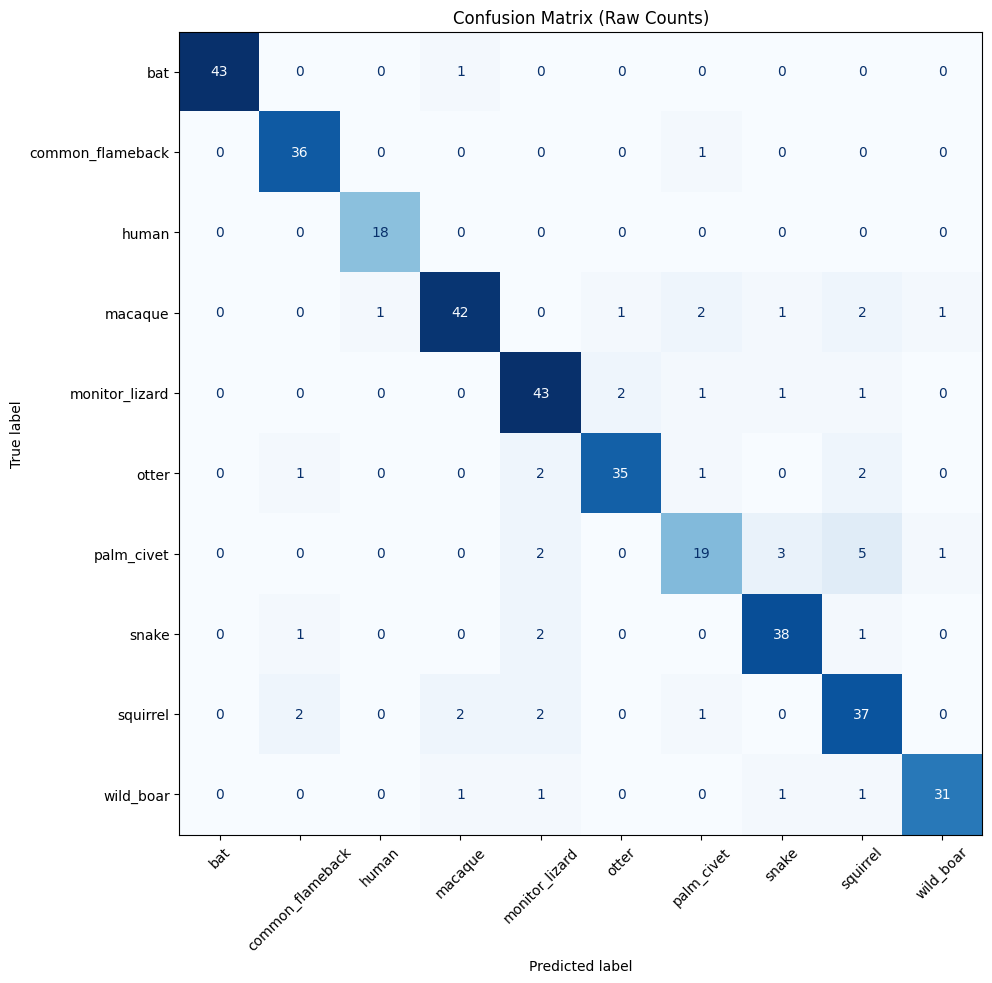

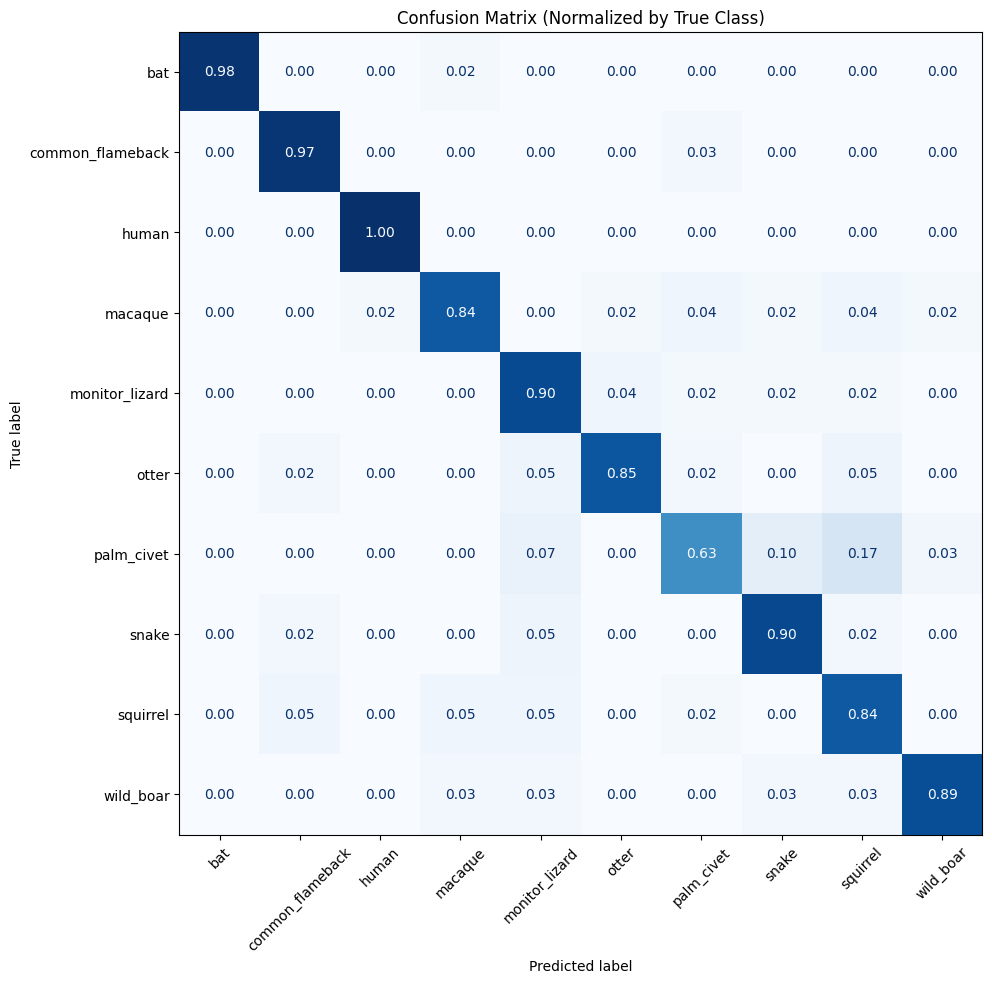

Classification Report:

                  precision    recall  f1-score   support

             bat     1.0000    0.9773    0.9885        44
common_flameback     0.9000    0.9730    0.9351        37
           human     0.9474    1.0000    0.9730        18
         macaque     0.9130    0.8400    0.8750        50
  monitor_lizard     0.8269    0.8958    0.8600        48
           otter     0.9211    0.8537    0.8861        41
      palm_civet     0.7600    0.6333    0.6909        30
           snake     0.8636    0.9048    0.8837        42
        squirrel     0.7551    0.8409    0.7957        44
       wild_boar     0.9394    0.8857    0.9118        35

        accuracy                         0.8792       389
       macro avg     0.8827    0.8804    0.8800       389
    weighted avg     0.8808    0.8792    0.8785       389



In [ ]:
# =========================================================
# CELL: Confusion matrix + per-class report
# =========================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Get predictions from the Keras model
y_prob = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

# Ground truth from your split cell
y_true = test_labels

# Safety check
assert len(y_true) == len(y_pred), f"Mismatch: y_true={len(y_true)}, y_pred={len(y_pred)}"

# ---------- Raw confusion matrix ----------
cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, xticks_rotation=45, values_format="d", cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Raw Counts)")
plt.tight_layout()
plt.show()

# ---------- Normalized confusion matrix (row-wise / recall view) ----------
cm_norm = confusion_matrix(
    y_true, y_pred,
    labels=np.arange(len(CLASS_NAMES)),
    normalize="true"
)

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, xticks_rotation=45, values_format=".2f", cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Normalized by True Class)")
plt.tight_layout()
plt.show()

# ---------- Per-class precision / recall / F1 ----------
print("Classification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4
))

In [ ]:
import tensorflow as tf

OLD_MODEL_PATH = "/content/drive/MyDrive/sg_edge_outputs/sg_edge_mobilenetv3small_224.keras"
old_model = tf.keras.models.load_model(OLD_MODEL_PATH)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

def evaluate_keras_model_with_confusion(model, test_ds, test_labels, class_names, title_prefix="Model"):
    y_prob = model.predict(test_ds, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_labels

    assert len(y_true) == len(y_pred), f"Mismatch: y_true={len(y_true)}, y_pred={len(y_pred)}"

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    cm_norm = confusion_matrix(
        y_true, y_pred,
        labels=np.arange(len(class_names)),
        normalize="true"
    )

    fig, ax = plt.subplots(figsize=(10, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, values_format="d", cmap="Blues", colorbar=False)
    plt.title(f"{title_prefix} - Confusion Matrix (Raw Counts)")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, values_format=".2f", cmap="Blues", colorbar=False)
    plt.title(f"{title_prefix} - Confusion Matrix (Normalized)")
    plt.tight_layout()
    plt.show()

    print(f"{title_prefix} - Classification Report:\n")
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    ))

    return y_true, y_pred

13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 789ms/step


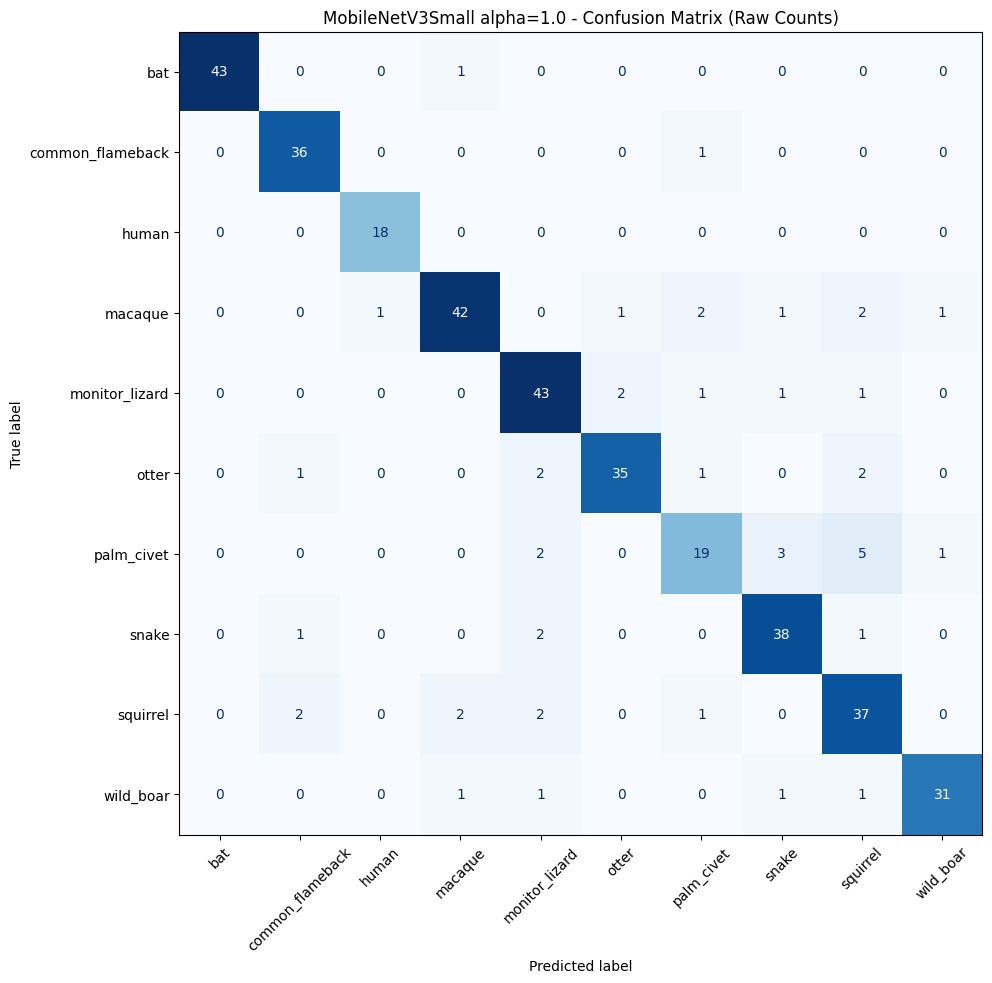

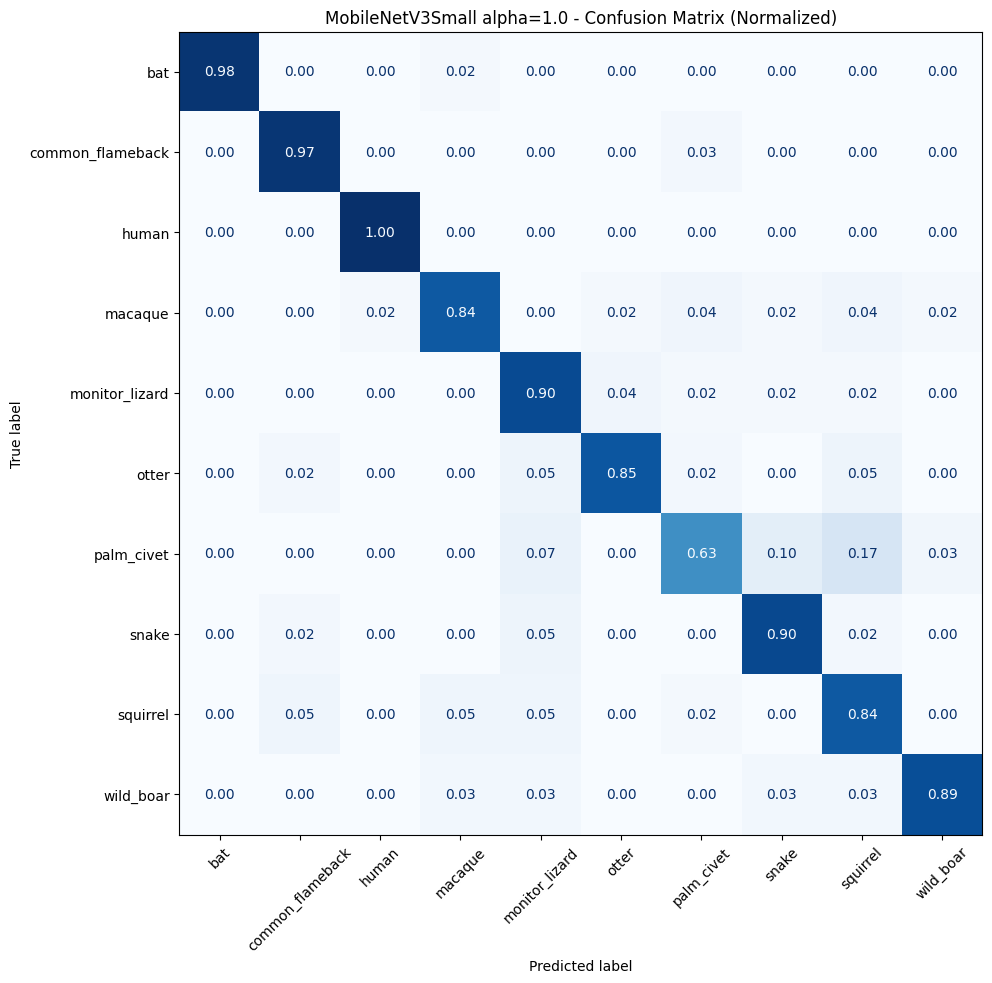

MobileNetV3Small alpha=1.0 - Classification Report:

                  precision    recall  f1-score   support

             bat     1.0000    0.9773    0.9885        44
common_flameback     0.9000    0.9730    0.9351        37
           human     0.9474    1.0000    0.9730        18
         macaque     0.9130    0.8400    0.8750        50
  monitor_lizard     0.8269    0.8958    0.8600        48
           otter     0.9211    0.8537    0.8861        41
      palm_civet     0.7600    0.6333    0.6909        30
           snake     0.8636    0.9048    0.8837        42
        squirrel     0.7551    0.8409    0.7957        44
       wild_boar     0.9394    0.8857    0.9118        35

        accuracy                         0.8792       389
       macro avg     0.8827    0.8804    0.8800       389
    weighted avg     0.8808    0.8792    0.8785       389

13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 772ms/step


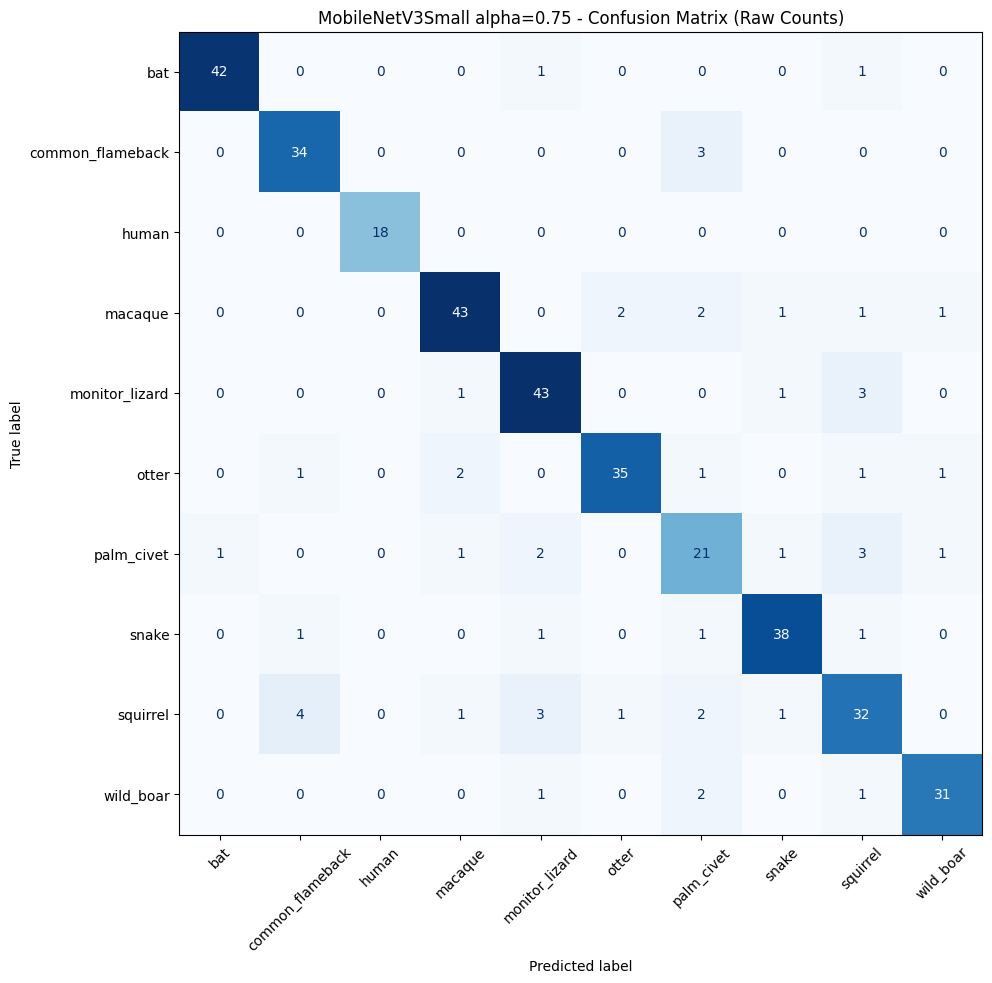

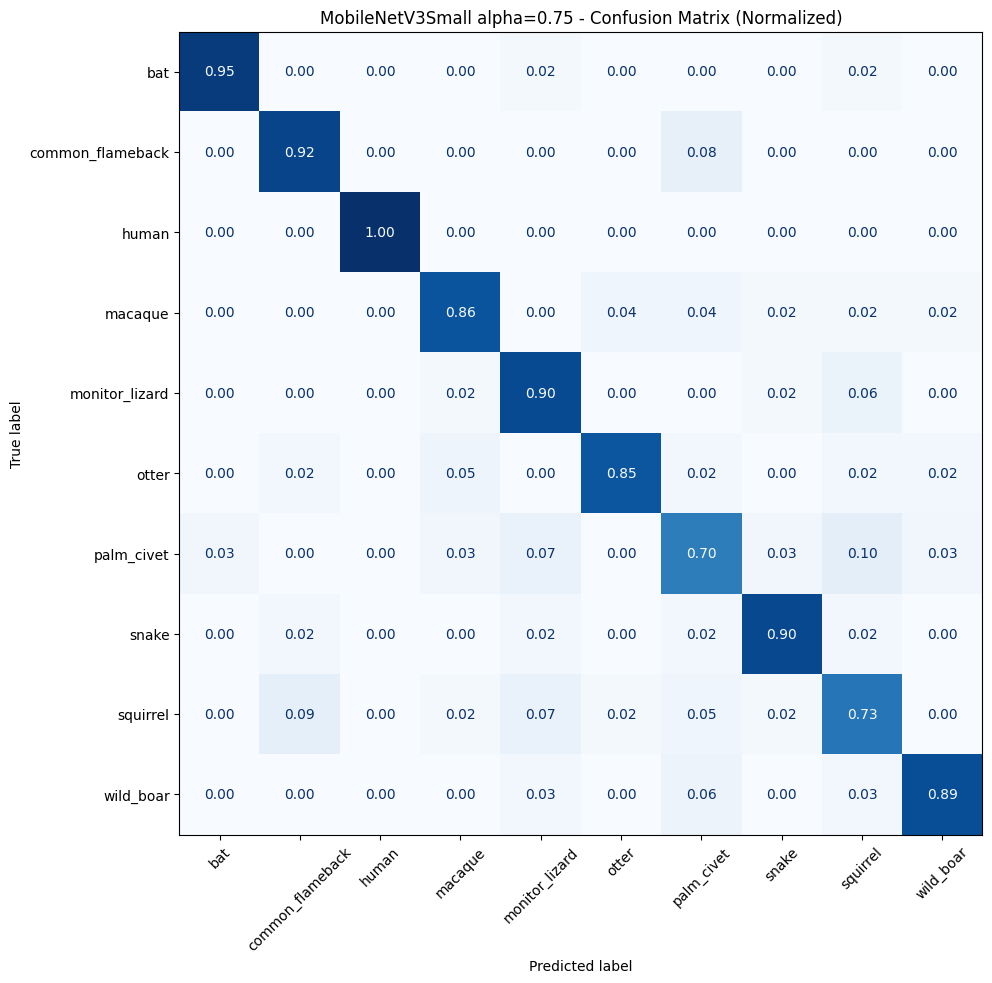

MobileNetV3Small alpha=0.75 - Classification Report:

                  precision    recall  f1-score   support

             bat     0.9767    0.9545    0.9655        44
common_flameback     0.8500    0.9189    0.8831        37
           human     1.0000    1.0000    1.0000        18
         macaque     0.8958    0.8600    0.8776        50
  monitor_lizard     0.8431    0.8958    0.8687        48
           otter     0.9211    0.8537    0.8861        41
      palm_civet     0.6562    0.7000    0.6774        30
           snake     0.9048    0.9048    0.9048        42
        squirrel     0.7442    0.7273    0.7356        44
       wild_boar     0.9118    0.8857    0.8986        35

        accuracy                         0.8663       389
       macro avg     0.8704    0.8701    0.8697       389
    weighted avg     0.8684    0.8663    0.8668       389



(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6,
        6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
        6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
        7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 

In [ ]:
# Current alpha=1.0 model already in memory as `model`
evaluate_keras_model_with_confusion(
    model,
    test_ds,
    test_labels,
    CLASS_NAMES,
    title_prefix="MobileNetV3Small alpha=1.0"
)

# Older alpha=0.75 model loaded from disk
evaluate_keras_model_with_confusion(
    old_model,
    test_ds,
    test_labels,
    CLASS_NAMES,
    title_prefix="MobileNetV3Small alpha=0.75"
)